# CNN Emotion Classification - Experiment

## Sample Images

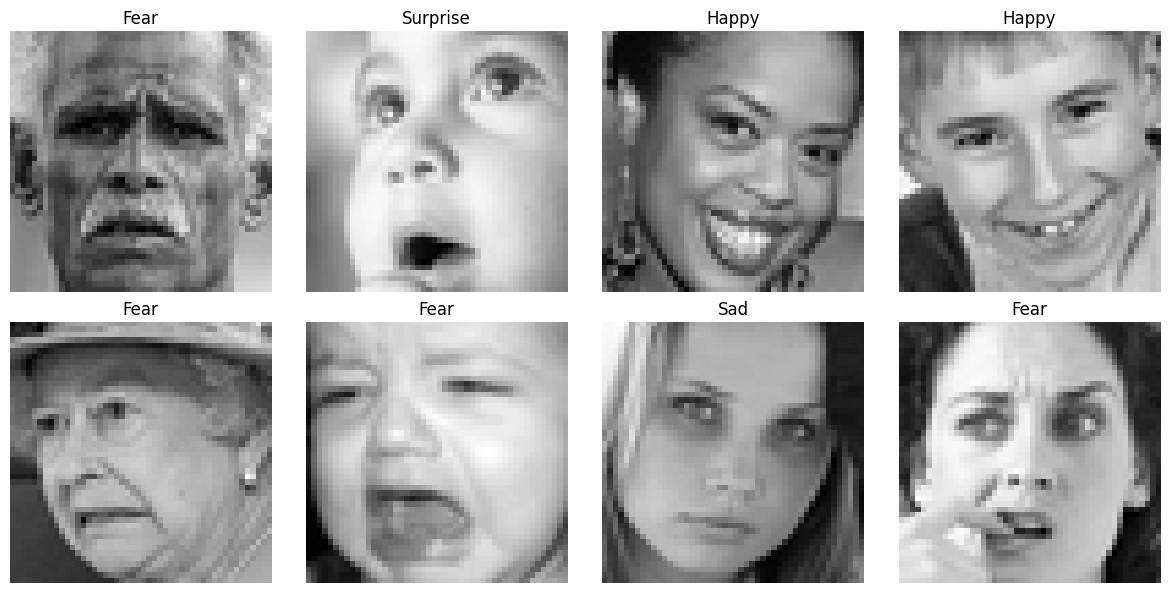

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import random

_root = Path.cwd()
ROOT = _root.parent if _root.name == "notebooks" else _root
sys.path.insert(0, str(ROOT / "src"))
from main import FERDataset

val_dataset = FERDataset(ROOT / "data" / "fer2013.csv", split="PublicTest")

indices = random.sample(range(len(val_dataset)), 8)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices):
    image, label = val_dataset[idx]

    plt.subplot(2, 4, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(FERDataset.class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Predictions

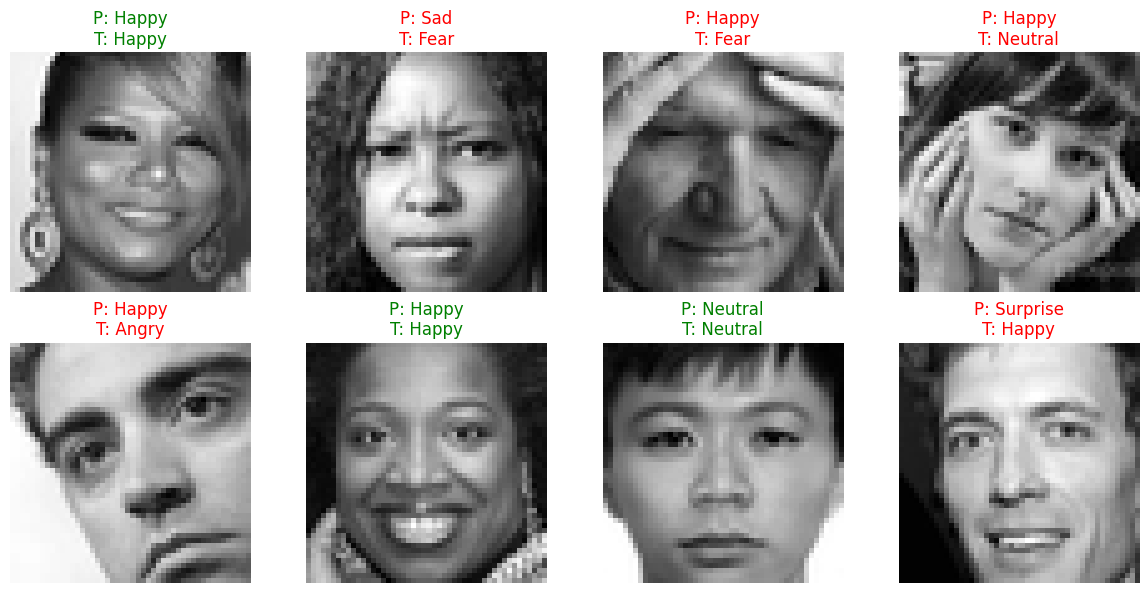

In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import random
import torch

_root = Path.cwd()
ROOT = _root.parent if _root.name == "notebooks" else _root
sys.path.insert(0, str(ROOT / "src"))
from main import FERDataset, SimpleCNN

val_dataset = FERDataset(ROOT / "data" / "fer2013.csv", split="PublicTest")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN()
model.load_state_dict(torch.load(ROOT / "best_model.pth", map_location=device))
model.eval()
model.to(device)

indices = random.sample(range(len(val_dataset)), 8)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices):
    image, label = val_dataset[idx]

    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(dim=1).item()

    plt.subplot(2, 4, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")

    title = f"P: {FERDataset.class_names[pred]}\nT: {FERDataset.class_names[label]}"
    color = "green" if pred == label else "red"
    plt.title(title, color=color)

    plt.axis("off")

plt.tight_layout()
plt.show()

## Confusion Matrix

[[155   0  35  77  88  20  92]
 [ 20   1   7   6  15   0   7]
 [ 47   0 117  61 101  70 100]
 [ 26   0  26 699  60  20  64]
 [ 63   0  57  84 253  18 178]
 [ 14   0  38  27  19 282  35]
 [ 34   0  34  83 101  10 345]]


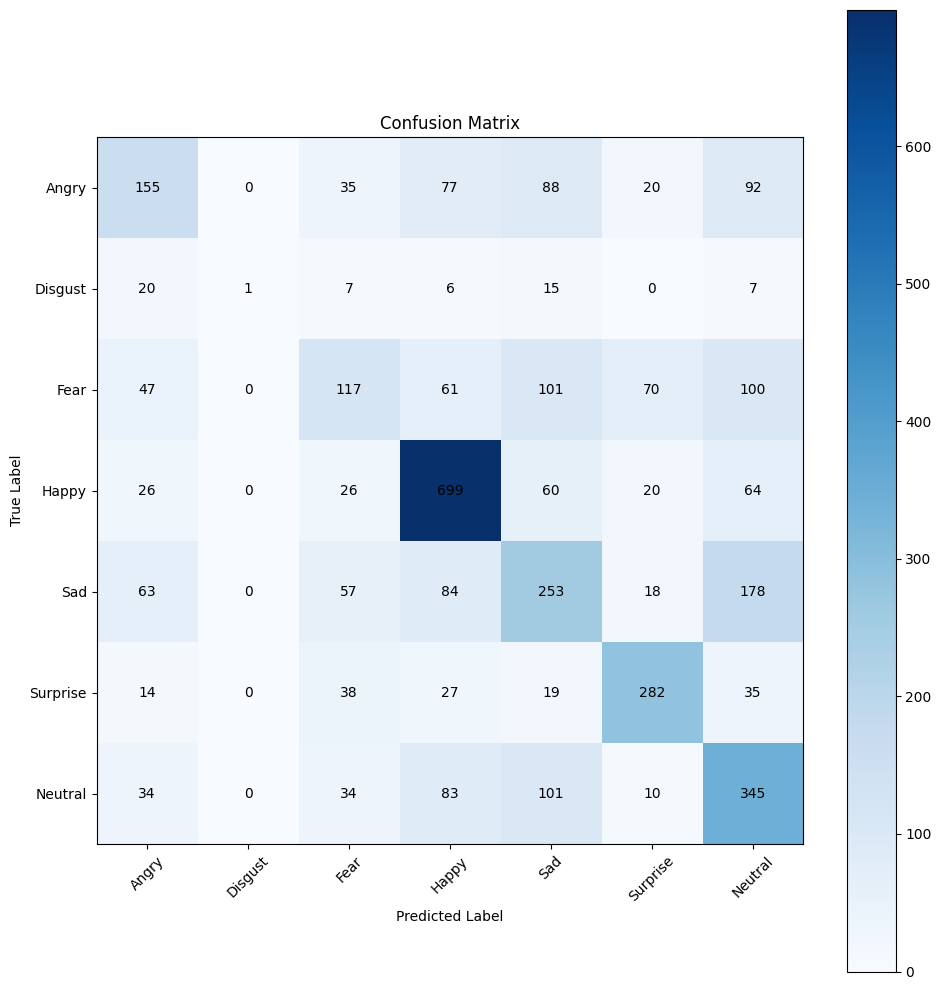

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

class_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

y_true = np.load(ROOT / "best_y_true.npy")
y_pred = np.load(ROOT / "best_y_pred.npy")

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4, 5, 6])
print(cm)

plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"), ha="center", va="center")

plt.tight_layout()
plt.show()

### Observations
- Happy has the strongest performance.
- Disjust has the least recognition.
- Negative emotions, such as anger, fear, and sadness, are often confused.

## Grad-CAM Visualization